# Phase 3: The NeuroGym Data Tour
Before we train the RNN, we need to understand what the data actually looks like. NeuroGym generates cognitive tasks with specific temporal phases:
1. **Fixation:** The network must output a 'fixation' action (usually class 0) and wait.
2. **Stimulus:** The noisy evidence is presented. The network must continue to fixate while internally accumulating evidence.
3. **Decision:** The stimulus turns off, and the network must output its choice based on the accumulated evidence.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from src.tasks.neurogym_wrapper import generate_single_trial

# We will use our wrapper to generate a single trial of the Perceptual Task
perceptual_obs, perceptual_target, p_dict = generate_single_trial('PerceptualDecisionMaking-v0', dt=20)

print(f"Observation Shape: {perceptual_obs.shape} (Timesteps, Features)")
print(f"Target Shape: {perceptual_target.shape} (Timesteps,)")

Observation Shape: (105, 3) (Timesteps, Features)
Target Shape: (105,) (Timesteps,)


c:\Users\sinde\anaconda3\envs\neuroai-project13\Lib\site-packages\gymnasium\envs\registration.py:481: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['paper_link', 'paper_name', 'tags']
  logger.warn(


### Visualizing Perceptual Decision Making (Low Integration)
In this task, the network receives a single stream of noisy evidence (e.g., dots moving left or right). Notice how the target changes from `0` (Fixate) to the correct choice (e.g., `1` or `2`) at the very end of the trial.

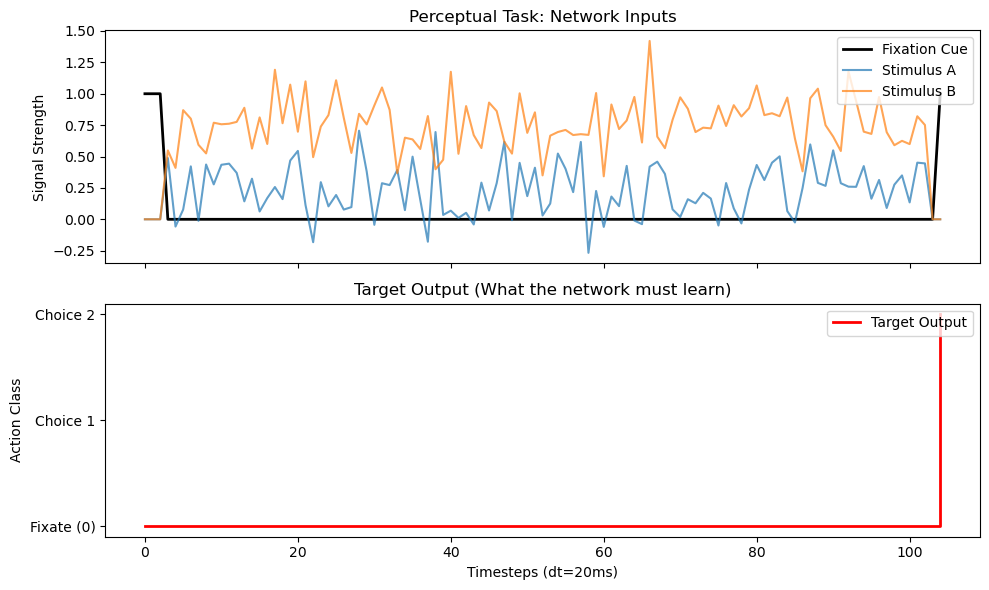

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot Inputs
axes[0].plot(perceptual_obs[:, p_dict['fixation']], label='Fixation Cue', color='black', linewidth=2)
axes[0].plot(perceptual_obs[:, p_dict['stimulus'][0]], label='Stimulus A', alpha=0.7)
axes[0].plot(perceptual_obs[:, p_dict['stimulus'][1]], label='Stimulus B', alpha=0.7)
axes[0].set_title('Perceptual Task: Network Inputs')
axes[0].set_ylabel('Signal Strength')
axes[0].legend(loc='upper right')

# Plot Targets
axes[1].plot(perceptual_target, label='Target Output', color='red', linewidth=2, drawstyle='steps-post')
axes[1].set_title('Target Output (What the network must learn)')
axes[1].set_ylabel('Action Class')
axes[1].set_xlabel('Timesteps (dt=20ms)')
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Fixate (0)', 'Choice 1', 'Choice 2'])
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Visualizing Context Decision Making (High Integration)
This is where synergy is expected to emerge! The network now receives **four** noisy stimulus channels (e.g., Motion Left, Motion Right, Color Red, Color Blue) AND **two** context channels. The network must use the context channel to figure out which pair of stimulus channels to pay attention to, and actively ignore the other pair.

c:\Users\sinde\anaconda3\envs\neuroai-project13\Lib\site-packages\gymnasium\envs\registration.py:481: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['paper_link', 'paper_name', 'tags']
  logger.warn(


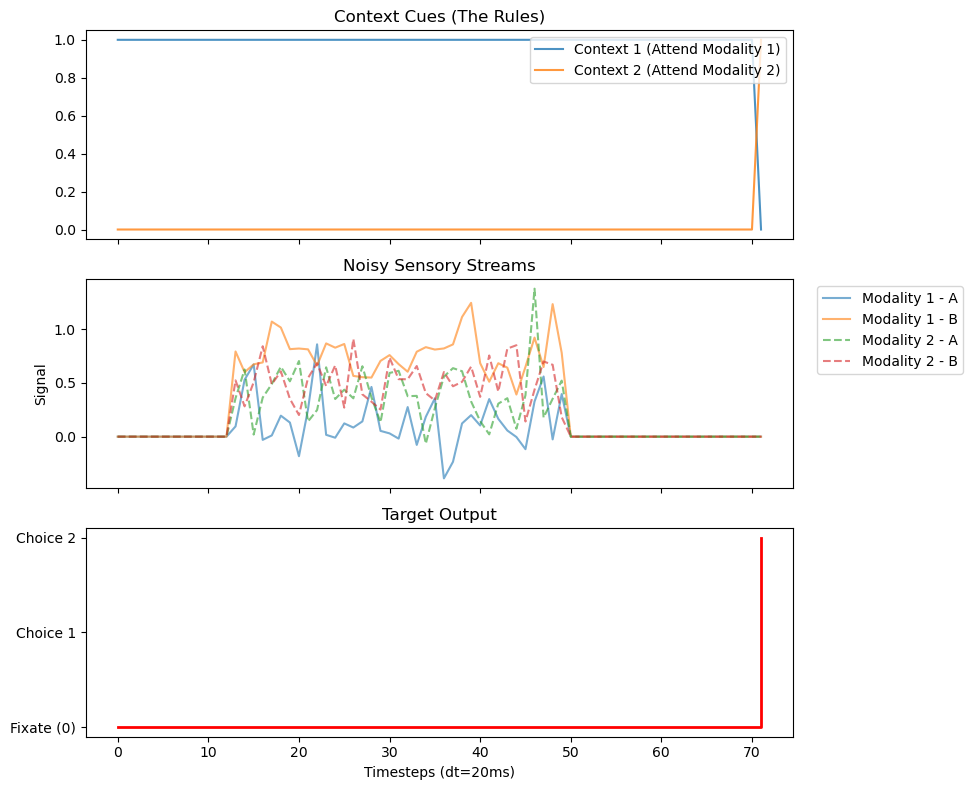

In [3]:
context_obs, context_target, c_dict = generate_single_trial('ContextDecisionMaking-v0', dt=20)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot Context Cues
axes[0].plot(context_obs[:, c_dict['context'][0]], label='Context 1 (Attend Modality 1)', alpha=0.8)
axes[0].plot(context_obs[:, c_dict['context'][1]], label='Context 2 (Attend Modality 2)', alpha=0.8)
axes[0].set_title('Context Cues (The Rules)')
axes[0].legend(loc='upper right')

# Plot Stimuli
axes[1].plot(context_obs[:, c_dict['stimulus1'][0]], label='Modality 1 - A', alpha=0.6)
axes[1].plot(context_obs[:, c_dict['stimulus1'][1]], label='Modality 1 - B', alpha=0.6)
axes[1].plot(context_obs[:, c_dict['stimulus2'][0]], label='Modality 2 - A', alpha=0.6, linestyle='--')
axes[1].plot(context_obs[:, c_dict['stimulus2'][1]], label='Modality 2 - B', alpha=0.6, linestyle='--')
axes[1].set_title('Noisy Sensory Streams')
axes[1].set_ylabel('Signal')
axes[1].legend(loc='upper right', bbox_to_anchor=(1.25, 1))

# Plot Targets
axes[2].plot(context_target, label='Target Output', color='red', linewidth=2, drawstyle='steps-post')
axes[2].set_title('Target Output')
axes[2].set_xlabel('Timesteps (dt=20ms)')
axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(['Fixate (0)', 'Choice 1', 'Choice 2'])

plt.tight_layout()
plt.show()